*7-15-2026, Subi Nair*

### Complete Water Balance for 2 basins

*   Generates the WBET for 2 basins, 1 basin at a time
*   Converts discharge to mm for WBET calculations
*   Removes months that do not have runoff data
*   Produces two .csv files for each huc
    * HUC_ID_wbet_monthly.csv
    * HUC_ID_wbet_water_year.csv

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import glob
import os

In [77]:
# clone the git repository
!git clone https://github.com/watrs-csumb/huc8basin-water-balance

# set working directory to the cloned repo so all paths are relative
%cd /content/huc8basin-water-balance

Cloning into 'huc8basin-water-balance'...
remote: Enumerating objects: 937, done.
remote: Counting objects: 100% (937/937), done.
remote: Compressing objects: 100% (889/889), done.
remote: Total 937 (delta 88), reused 868 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (937/937), 8.81 MiB | 14.64 MiB/s, done.
Resolving deltas: 100% (88/88), done.
/content/huc8basin-water-balance


### Set up constants and data sources
Includes the conversions for units and a dictionary for precipitation datasets (later down the line)

In [78]:
#include conversion units here
cfs_to_af_factor = 1.9835
ft_to_mm = 304.8

precip_dict = {
    'gridmet': 'gridmet_monthly_precipitation_package',
    'chirps': 'chirps_monthly_precipitation_package',
    'agera5' : 'AgEra-5_monthly_precipitation_package',
    'nclimgrid' : 'nclimgrid_monthly_precipitation_package',
    'prism' : 'prism_monthly_precipitation_package',
    'rdpa' : 'rdpa_monthly_precipitation_package'
}


### Function block
Functions by AJ Purdy


*   `get_precip_data` accepts the hucID and a single precip data product
*   `get_et_data` takes hucID and et model to collect observed et values
*    `read_q_from_gaugeID` helper function used within `read_one_or_more_gauges` to get q for selected gauge
*    `read_one_or_more_gauges` returns a monthly dataframe for one or more gauges and a helper to get q_in and q_out for `get_q_data`
*    `get_q_data` produces the dataframe with q values for huc



In [46]:
def get_precip_data(huc8id, product):
    '''
    input parameters:
    huc8id: USGS HUC8ID [string or INT]
    product: precipitation data product nickname (e.g., 'gridmet')

    output:
    out_df: dataframe of monthly precipitation timeseries for huc8id basin
    '''
    #Get the actual folder name using the dictionary
    folder_name = precip_dict.get(product)
    if not folder_name:
        raise ValueError(f"Product '{product}' not found in precip_dict.")

    # Build the glob pattern using the folder name and the HUC ID
    # Matches: data/p/gridmet_monthly_precipitation_package/*18090202*.csv
    search_pattern = os.path.join('data', 'p', folder_name, f'*{str(huc8id)}*.csv')
    file_matches = glob.glob(search_pattern)

    # Throw error if file is not in the folder
    if not file_matches:
        raise FileNotFoundError(f"No file found for HUC8 ID {huc8id} under product '{product}'")

    filename = file_matches[0]

    # Read and process the DataFrame
    out_df = pd.read_csv(filename)
    out_df['date'] = pd.to_datetime(out_df['date'])
    out_df.rename(columns={'precipitation_mm': f'{product}_pr_mm'}, inplace=True)
    out_df.set_index('date', inplace=True)

    return out_df

def get_et_data(huc8id, model):
    '''
    input parameters:
    huc8id: USGS HUC8ID [string or INT]
    model: OpenET model name data product from data/et/

    output:
    out_df: dataframe of monthly evapotranspiration timeseries for huc8id basin
    '''
    filename = glob.glob(f'data/et/*{model}*.csv')[0]
    out_df = pd.read_csv(filename)
    out_df = out_df.loc[out_df.huc8==huc8id].copy()
    out_df['date']=pd.to_datetime(out_df['year_month'])
    out_df.set_index('date',inplace=True)
    out_df.rename(columns={'data_val': f'{model}_ET_mm'}, inplace=True)
    return out_df

def read_q_from_gaugeID(gaugeID):
    '''
    input parameters
    gaugeID: USGS streamflow gauge ID

    output:
    single_gauge: pandas dataframe aggregate monthly streamflow
    '''
    all_gauges = pd.read_csv('data/q/all_gauges_monthly_streamflow_summary.csv')
    single_gauge = all_gauges.loc[all_gauges.site_no==gaugeID].copy()
    single_gauge['date']=pd.to_datetime(single_gauge['year_month'])
    single_gauge.set_index('date',inplace=True)
    single_gauge['sum_daily_mean_cfs']
    return single_gauge

def read_one_or_more_gauges(gauges):
    """
    Reads one or more gauges and returns a monthly dataframe.
    Expects gauges to be either NaN, one gauge, or multiple gauges separated by commas.
    """

    if pd.isna(gauges):
        return None

    gauges = str(gauges)

    q_list = []

    for gauge in gauges.split(","):
        gauge = gauge.strip()

        # Handles values like "USGS-12345678"
        if "-" in gauge:
            gauge_id = gauge.split("-")[1]
        else:
            gauge_id = gauge

        q = read_q_from_gaugeID(int(gauge_id))
        q_list.append(q)

    if len(q_list) == 1:
        return q_list[0]

    # Combine multiple gauges by month
    q_all = pd.concat(q_list, ignore_index=True)

    q_sum = (
        q_all
        .groupby(["year_month", "water_year", "year", "month"], as_index=False)
        .agg({
            "mean_discharge_cfs": "sum",
            "sum_daily_mean_cfs": "mean",
            "n_days": "max",
            "n_missing_values": "min"
        })
    )

    q_sum["site_no"] = str(gauges)

    return q_sum[
        [
            "site_no",
            "year_month",
            "water_year",
            "year",
            "month",
            "mean_discharge_cfs",
            "sum_daily_mean_cfs",
            "n_days",
            "n_missing_values",
        ]
    ]

def get_q_data(huc8id):
    """
    input parameters:
    huc8id: USGS HUC8ID [string or int]

    output:
    q_df: dataframe of aggregate monthly discharge inflows and outflows for huc8id basin
    """

    meta = pd.read_csv("data/metadata/streamflow_gauges.csv")
    meta = meta.loc[meta.HUCID == huc8id]

    if meta.empty:
        raise ValueError(f"No metadata found for HUCID {huc8id}")

    gauges_in = meta["gauge_in"].iloc[0]
    gauges_out = meta["gauge_out"].iloc[0]



    q_in = read_one_or_more_gauges(gauges_in)
    q_out = read_one_or_more_gauges(gauges_out)

    # Case 1: both inflow and outflow gauges exist
    if q_in is not None and q_out is not None:
        q_df = q_out.merge(
            q_in,
            on=["year_month", "water_year", "year", "month"],
            how="outer",
            suffixes=("_out", "_in")
        )

        q_df["mean_discharge_cfs"] = (
            q_df["mean_discharge_cfs_out"].fillna(0)
            - q_df["mean_discharge_cfs_in"].fillna(0)
        )

        q_df["sum_daily_mean_cfs"] = (
            q_df["sum_daily_mean_cfs_out"].fillna(0)
            - q_df["sum_daily_mean_cfs_in"].fillna(0)
        )

        q_df["n_days"] = q_df[["n_days_out", "n_days_in"]].max(axis=1)

        q_df["n_missing_values"] = (
            q_df["n_missing_values_out"].fillna(0)
            + q_df["n_missing_values_in"].fillna(0)
        )

        q_df["site_no"] = huc8id

        q_df = q_df[
            [
                "site_no",
                "year_month",
                "water_year",
                "year",
                "month",
                "mean_discharge_cfs",
                "sum_daily_mean_cfs",
                "n_days",
                "n_missing_values",
            ]
        ]

    # Case 2: only outflow exists
    elif q_out is not None:
        q_df = q_out.copy()
        q_df["site_no"] = huc8id

    # Case 3: only inflow exists
    elif q_in is not None:
        q_df = q_in.copy()

        # Since this is only inflow, make it negative net discharge
        q_df["mean_discharge_cfs"] = -q_df["mean_discharge_cfs"]
        q_df["sum_daily_mean_cfs"] = -q_df["sum_daily_mean_cfs"]

        q_df["site_no"] = huc8id

    # Case 4: neither exists
    else:
        q_df = pd.DataFrame(
            columns=[
                "site_no",
                "year_month",
                "water_year",
                "year",
                "month",
                "mean_discharge_cfs",
                "sum_daily_mean_cfs",
                "n_days",
                "n_missing_values",
            ]
        )

    return q_df



In [61]:
# check the metadata file
meta = pd.read_csv('data/metadata/streamflow_gauges.csv')
meta.iloc[1,:]


,1
HUCID,18090202
gauge_in,NaN
gauge_out,USGS-10251330


### Select a HUCID here
Choose a hucID to build the dataframes, currently takes one HUC at a time

In [71]:
## Select HUC

#huc8id = 18090202
huc8id = 17060303

pr_df = get_precip_data(huc8id,'gridmet')
et_df = get_et_data(huc8id,'ensemble')
q_df = get_q_data(huc8id)

#print(pr_df)
#print(et_df)
#print(q_df)


### Combine all dataframes
Combine the precipitation, et, and runoff dataframe, plot to check precip and observed et values.

<Axes: xlabel='water_year'>

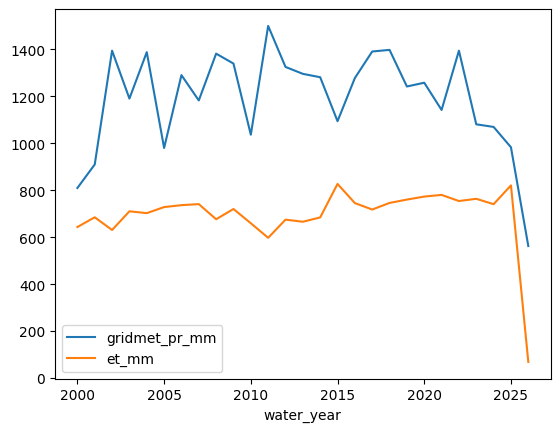

In [72]:
# bring together columns from the three dfs
all_dfs = [pr_df,
           et_df[['areaacres','huc8','et_mm','units',]],
           q_df[['sum_daily_mean_cfs','n_days','n_missing_values','water_year']]]

# Make sure all indexes are datetime
for df in all_dfs:
    df.index = pd.to_datetime(df.index)

# Find the overlapping date range
start = max(df.index.min() for df in all_dfs)
end = min(df.index.max() for df in all_dfs)

# Concatenate columns, keeping only overlapping datetimes
df_all = (
    pd.concat(all_dfs, axis=1, join="inner")
    .loc[start:end]
    .sort_index()
)

# Plot to check precip and et values
df_all[['gridmet_pr_mm','et_mm','water_year']].groupby('water_year').sum().plot()



### QC Filter for months with no data
This section removes any months with n_missing_values > 0, so all the final wbet calculations will use months that have complete data.

In [73]:
## Filter out water years that have incomplete data
# Remove months where any day has missing streamflow gauge values
df_all = df_all[df_all['n_missing_values'] == 0]

# Count the remaining months left in each water year
wy_counts = df_all.groupby('water_year').size()

# Filter df_all to keep only those complete water years
complete_water_years = wy_counts[wy_counts == 12].index
df_all = df_all[df_all['water_year'].isin(complete_water_years)]

# print(df_all.columns.tolist())
# print(df_all)


### Conversions


---


This section first converts discharge (`sum_daily_mean_cfs`) into acre-feet, then converts the acre-feet into a depth in mm ((acre-feet / area in acres) * 304.8)

*Note: converting discharge to acre feet can also be done with (`mean_discharge_cfs`) x (`n_days`), but the approach with `sum_daily_mean_cfs` already does this and is cleaner*

Then it creates a 'wbet' column that has the calculated water balance et values using precip and q

WBET = P - Q

`wy_summary` contains the water year aggregation table and is plotted at the end to compare WBET with observed ET

<Axes: xlabel='water_year'>

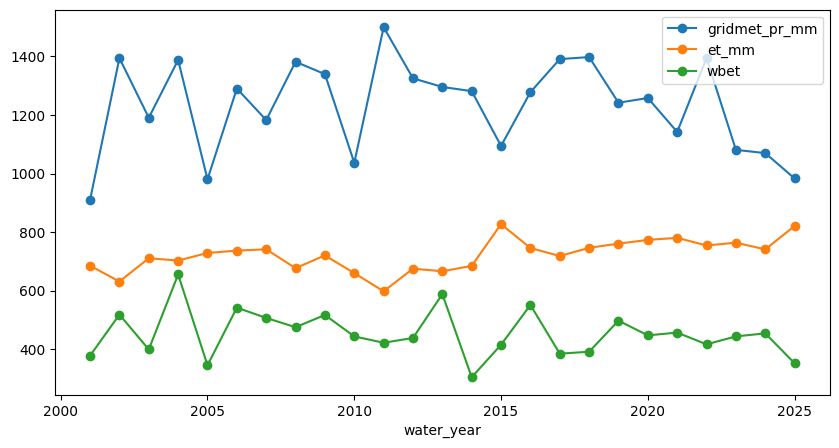

In [76]:

# convert daily runoff means to acre feet
df_all['acre_feet'] = df_all['sum_daily_mean_cfs'] * cfs_to_af_factor

# acrefeet to water depth in mm
df_all['depth_mm'] = (df_all['acre_feet'] / df_all['areaacres']) * ft_to_mm

# Calculate monthly Water Balance ET (Precipitation - Streamflow Depth (in mm))
df_all['wbet'] = df_all['gridmet_pr_mm'] - df_all['depth_mm']

# Aggregate all columns by water year
wy_summary = df_all[['water_year','gridmet_pr_mm', 'et_mm', 'depth_mm', 'wbet']].groupby('water_year').sum()

# Optional: Display the water year summary table
# print("--- Water Year Summary ---")
# print(wy_summary)

# Plot the comparison of Precipitation, OpenET (et_mm), and your calculated WBET (et_calc)
wy_summary[['gridmet_pr_mm', 'et_mm', 'wbet']].plot(kind='line', marker='o', figsize=(10, 5))

### CSV Output
Creates two files per HUCID, one for monthly WBET and the other aggregated into water years.

In [75]:
## CSV output generation

# name the file paths
monthly_csv_path = f'HUC_{huc8id}_wbet_monthly.csv'
wy_csv_path = f'HUC_{huc8id}_wbet_water_year.csv'

df_all.to_csv(monthly_csv_path)
wy_summary.to_csv(wy_csv_path)

print(f"Saved complete monthly data to: {monthly_csv_path}")
print(f"Saved complete water year data to: {wy_csv_path}")

Saved complete monthly data to: HUC_17060303_wbet_monthly.csv
Saved complete water year data to: HUC_17060303_wbet_water_year.csv
